C:\Users\nithish\AppData\Local\Temp\ipykernel_6516\2507331574.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql_query, db_connection)


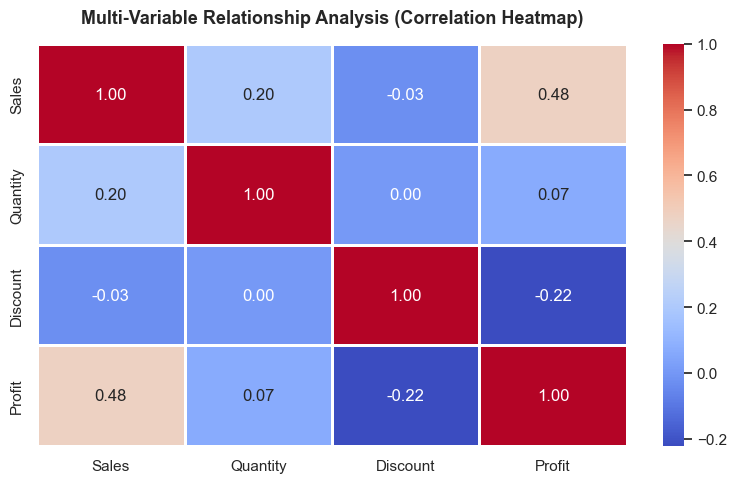

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


sns.set_theme(style="whitegrid")

try:
    db_connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="nithya123",
        database="apex"
    )
except mysql.connector.Error as err:
    print(f"Database Connection Error: {err}")
    raise


sql_query = "SELECT * FROM `sample - superstore`;"
df = pd.read_sql(sql_query, db_connection)
db_connection.close()

# STEP 3: ADVANCED VISUALIZATIONS & MULTI-VARIABLE RELATIONSHIPS

# A. Chart 1: The Multi-Variable Relationship Analysis (Correlation Matrix)
plt.figure(figsize=(8, 5))
relationship_vars = ['Sales', 'Quantity', 'Discount', 'Profit']
correlation_data = df[relationship_vars].corr()

sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Multi-Variable Relationship Analysis (Correlation Heatmap)', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()


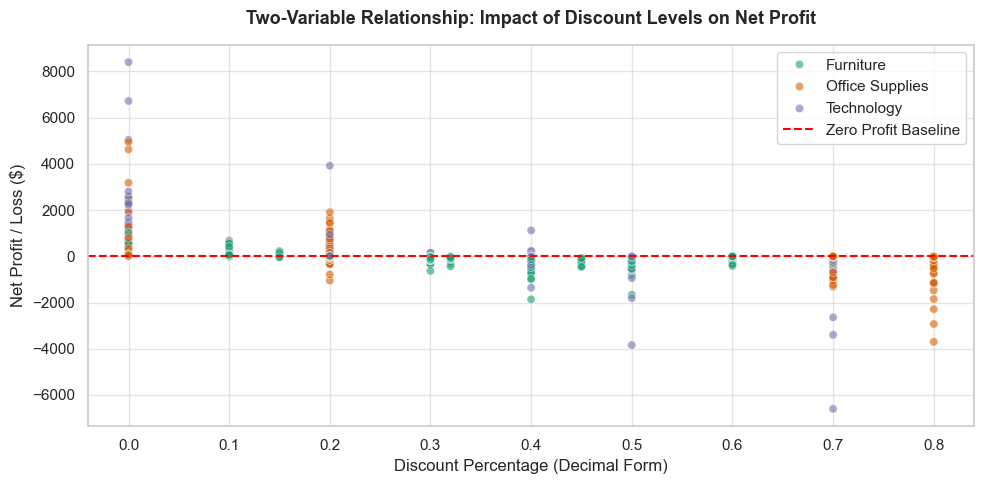

In [6]:
# B. Chart 2: Direct Two-Variable Relationship Deep-Dive (Discount vs Profit)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, palette='Dark2')

# Adding a zero-line baseline to instantly separate profitable deals from losses
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Profit Baseline')
plt.title('Two-Variable Relationship: Impact of Discount Levels on Net Profit', fontsize=13, weight='bold', pad=15)
plt.xlabel('Discount Percentage (Decimal Form)')
plt.ylabel('Net Profit / Loss ($)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()